# Week 42, Tuesday session: the backward pass, step by step

**FYS-STK3155/4155, Tuesday October 13, 2026 — flipped classroom**

Today there is **one case**, and it is the skeleton of this week's exercises
(`exercisesweek42.ipynb`, deadline **Friday October 16 at midnight**): the
gradient of a neural network computed by hand with the backpropagation
algorithm, checked at every step against `jax.grad`. We work in groups through
the six steps below on examples of our own — a 3–4–2 network, then the
digits data — so that you do each step once with us and once alone on the
networks of the exercise set. After each step there are checkpoints; after the
case, the insight questions are discussed in plenum.

The conventions are those of the exercises: steps 1–3 use the
**single-vector convention** (one input vector at a time, $W$ of shape
(outputs, inputs), $z = Wx + b$), steps 4–6 the **batched convention** of the
lecture notes and of Monday's code (samples in rows, $W$ of shape (inputs,
outputs), $Z = XW + b$, Eq. (8.21)). Keeping track of the shapes is the whole
point of this session.

In [1]:
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)   # 64-bit floats, so that hand and JAX agree to ~1e-15
import jax.numpy as jnp
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(2026)
BLUE, RED, GREEN, GREY = "#004488", "#BB5566", "#228833", "#777777"


def sigmoid(z):
    return 1.0/(1.0 + jnp.exp(-z))


def sigmoid_der(z):
    s = sigmoid(z)
    return s*(1.0 - s)


def ReLU(z):
    return jnp.where(z > 0, z, 0.0)


def ReLU_der(z):
    return jnp.where(z > 0, 1.0, 0.0)


def mse(predict, target):
    return jnp.mean((predict - target)**2)


def mse_der(predict, target):
    return 2.0*(predict - target)/predict.size     # the mean brings a factor 2/n

## Case 1: the backward pass in six steps

### Step 1 — shapes first, then one layer by hand (exercises 2–3)

A layer with 3 inputs and 4 outputs: $W$ has shape $(4, 3)$, $b$ shape
$(4,)$, and for one input vector $x$ of shape $(3,)$, $z = Wx + b$ and $a =
\sigma(z)$ have shape $(4,)$. **Before running anything**, write down the
shapes of $\partial C/\partial W$ and $\partial C/\partial b$. The rule: the
gradient of a scalar with respect to an array has the shape of that array —
one number per parameter.

The chain rule for one layer with the mean squared error as cost:

$$
\frac{\partial C}{\partial W} = \frac{\partial C}{\partial a}\frac{\partial a}{\partial z}\frac{\partial z}{\partial W},\qquad
\frac{\partial C}{\partial b} = \frac{\partial C}{\partial a}\frac{\partial a}{\partial z}\frac{\partial z}{\partial b}.
$$

The first two factors are shared: their product is the *error* of the layer,
$\delta = \partial C/\partial z = (\partial C/\partial a)\,\sigma'(z)$, Eq.
(8.59)–(8.61). Then $\partial z_j/\partial b_j = 1$ gives $\partial C/\partial
b = \delta$ (8.62), and $\partial z_j/\partial W_{ji} = x_i$ gives $\partial
C/\partial W_{ji} = \delta_j x_i$ (8.60): an outer product, the shape of $W$.

In [2]:
x = rng.random(3)
target = rng.random(4)
W = rng.normal(0, 1/np.sqrt(3), (4, 3))
b = np.zeros(4) + 0.01


def feed_forward_one_layer(W, b, x):
    z = W @ x + b
    a = sigmoid(z)
    return a


def cost_one_layer(W, b, x, target):
    return mse(feed_forward_one_layer(W, b, x), target)


# the forward pass, keeping z and a
z = W @ x + b
a = sigmoid(z)
print("shapes: x", x.shape, " W", W.shape, " b", b.shape, " z", z.shape, " a", a.shape)

# the backward pass, by hand
dC_da = mse_der(a, target)                 # (4,)
dC_dz = dC_da * sigmoid_der(z)             # (4,)   the error delta
dC_dW = np.outer(dC_dz, x)                 # (4, 3) delta_j x_i
dC_db = dC_dz                              # (4,)
print("gradient shapes: dC/dW", dC_dW.shape, " dC/db", dC_db.shape)

# the check
W_g, b_g = jax.grad(cost_one_layer, argnums=(0, 1))(W, b, x, target)
print("agree with jax.grad:", np.allclose(dC_dW, W_g), np.allclose(dC_db, b_g),
      f"  (max |difference| {max(np.abs(dC_dW - W_g).max(), np.abs(dC_db - b_g).max()):.1e})")
print("delta =", np.asarray(dC_dz))

shapes: x (3,)  W (4, 3)  b (4,)  z (4,)  a (4,)
gradient shapes: dC/dW (4, 3)  dC/db (4,)


agree with jax.grad: True True   (max |difference| 1.4e-17)
delta = [ 0.01244665  0.02570272 -0.03948489 -0.04619773]


**Checkpoint.** `dC_dW` has shape $(4, 3)$ and `dC_db` shape $(4,)$ — the
shapes of $W$ and $b$ — and both agree with `jax.grad` to machine precision.
Two things to try: forget the factor $2/n$ in `mse_der` (the check fails, but
the gradient is right *up to a constant*, which a learning rate would silently
absorb); and replace `np.outer(dC_dz, x)` by `dC_dz * x` (a shape error, or
worse, silent broadcasting if the sizes happen to match).

### Step 2 — two layers: the error travels backwards through $W^T$ (exercise 4)

A 3–4–2 network, sigmoid in both layers. The last layer is step 1 with $a_1$
in place of $x$. For the first layer we need $\partial C/\partial a_1$, and
$C$ depends on $a_1$ only through $z_2 = W_2 a_1 + b_2$: $\partial
z_{2,k}/\partial a_{1,j} = W_{2,kj}$, so

$$
\frac{\partial C}{\partial a_1} = W_2^T\,\delta_2,\qquad
\delta_1 = \frac{\partial C}{\partial a_1}\circ\sigma'(z_1),
$$

Eq. (8.64): the error is pulled back through the *transpose* of the weights
(the sum runs over the receiving nodes $k$) and modulated by the local
derivative. Shapes: $W_2^T$ is $(4, 2)$, $\delta_2$ is $(2,)$, so
$\partial C/\partial a_1$ is $(4,)$ — the shape of $a_1$, as it must be.

In [3]:
target = rng.random(2)
W1, b1 = rng.normal(0, 1/np.sqrt(3), (4, 3)), np.zeros(4) + 0.01
W2, b2 = rng.normal(0, 1/np.sqrt(4), (2, 4)), np.zeros(2) + 0.01
layers = [(W1, b1), (W2, b2)]

# forward, saving everything
z1 = W1 @ x + b1;  a1 = sigmoid(z1)
z2 = W2 @ a1 + b2; a2 = sigmoid(z2)

# backward: last layer first
dC_da2 = mse_der(a2, target)
dC_dz2 = dC_da2 * sigmoid_der(z2)          # delta_2, shape (2,)
dC_dW2 = np.outer(dC_dz2, a1)              # (2, 4)
dC_db2 = dC_dz2
# then the first layer
dC_da1 = W2.T @ dC_dz2                     # (4, 2) @ (2,) -> (4,)   Eq. (8.64), the pull-back
dC_dz1 = dC_da1 * sigmoid_der(z1)          # delta_1, shape (4,)
dC_dW1 = np.outer(dC_dz1, x)               # (4, 3)
dC_db1 = dC_dz1
print("shapes: dC/dW1", dC_dW1.shape, " dC/db1", dC_db1.shape, " dC/dW2", dC_dW2.shape, " dC/db2", dC_db2.shape)


def feed_forward_two_layers(layers, x):
    (W1, b1), (W2, b2) = layers
    a1 = sigmoid(W1 @ x + b1)
    return sigmoid(W2 @ a1 + b2)


def cost_two_layers(layers, x, target):
    return mse(feed_forward_two_layers(layers, x), target)


grads_jax = jax.grad(cost_two_layers, argnums=0)(layers, x, target)   # a list of (dW, db) with the shapes of layers
print("agree with jax.grad:", [(np.allclose(dW, dW_j), np.allclose(db, db_j))
                                for (dW, db), (dW_j, db_j) in zip([(dC_dW1, dC_db1), (dC_dW2, dC_db2)], grads_jax)])
print("|delta_2| =", np.linalg.norm(dC_dz2), "  |delta_1| =", np.linalg.norm(dC_dz1),
      f"  ratio {np.linalg.norm(dC_dz1)/np.linalg.norm(dC_dz2):.2f}")

shapes: dC/dW1 (4, 3)  dC/db1 (4,)  dC/dW2 (2, 4)  dC/db2 (2,)


agree with jax.grad: [(True, True), (True, True)]
|delta_2| = 0.06880320574268407   |delta_1| = 0.013437147838456932   ratio 0.20


**Checkpoint.** `jax.grad` of a function of a *list of tuples of arrays*
returns a gradient with the same structure — a list of $(dW, db)$ with exactly
the shapes of the layers — and all four agree with the hand-written gradient.
Note the ratio $|\delta_1|/|\delta_2|$: the error shrinks on its way back
through $W_2^T$ and $\sigma'(z_1) \le 1/4$. With ten such layers it would
shrink by $4^{-10}$ (Section 8.9). An earlier layer would need nothing new:
the same two lines, with $W_1^T$ and $\sigma'(z_0)$.

### Step 3 — any number of layers: the loop of Eqs. (8.65)–(8.68) (exercise 5)

The forward pass must **save** every layer input and every $z$, because the
backward pass needs $f'(z_l)$ for (8.66) and the layer input $a_{l-1}$ for
(8.68). Then one loop from the last layer to the first: at the last layer
$\partial C/\partial a$ comes from the cost; at every other layer it comes
from the layer above, $W_{l+1}^T\,\delta_{l+1}$. Different activations per
layer are no problem as long as each comes with its derivative.

In [4]:
def create_layers(network_input_size, layer_output_sizes, rng):
    """W of shape (outputs, inputs): the single-vector convention."""
    layers = []
    i_size = network_input_size
    for layer_output_size in layer_output_sizes:
        W = rng.normal(0, 1/np.sqrt(i_size), (layer_output_size, i_size))
        b = np.zeros(layer_output_size) + 0.01
        layers.append((W, b))
        i_size = layer_output_size
    return layers


def feed_forward(input, layers, activation_funcs):
    a = input
    for (W, b), activation_func in zip(layers, activation_funcs):
        a = activation_func(W @ a + b)
    return a


def cost(layers, input, activation_funcs, target):
    return mse(feed_forward(input, layers, activation_funcs), target)


def feed_forward_saver(input, layers, activation_funcs):
    layer_inputs, zs = [], []
    a = input
    for (W, b), activation_func in zip(layers, activation_funcs):
        layer_inputs.append(a)
        z = W @ a + b
        a = activation_func(z)
        zs.append(z)
    return layer_inputs, zs, a


def backpropagation(input, layers, activation_funcs, target, activation_ders, cost_der=mse_der):
    layer_inputs, zs, predict = feed_forward_saver(input, layers, activation_funcs)
    layer_grads = [() for layer in layers]
    for i in reversed(range(len(layers))):
        layer_input, z, activation_der = layer_inputs[i], zs[i], activation_ders[i]
        if i == len(layers) - 1:
            dC_da = cost_der(predict, target)            # Eq. (8.65): from the cost
        else:
            (W, b) = layers[i + 1]
            dC_da = W.T @ dC_dz                          # Eq. (8.66): from the layer above
        dC_dz = dC_da * activation_der(z)                # the error delta of layer i
        dC_dW = np.outer(dC_dz, layer_input)             # Eq. (8.68)
        dC_db = dC_dz                                    # Eq. (8.67)
        layer_grads[i] = (dC_dW, dC_db)
    return layer_grads


layers = create_layers(3, [5, 4, 2], rng)
activation_funcs = [sigmoid, ReLU, sigmoid]
activation_ders = [sigmoid_der, ReLU_der, sigmoid_der]
x = rng.random(3)
target = rng.random(2)

layer_grads = backpropagation(x, layers, activation_funcs, target, activation_ders)
layer_grads_jax = jax.grad(cost, argnums=0)(layers, x, activation_funcs, target)
print("shapes:", [(dW.shape, db.shape) for dW, db in layer_grads])
print("agree with jax.grad:", [(np.allclose(dW, dW_j), np.allclose(db, db_j))
                                for (dW, db), (dW_j, db_j) in zip(layer_grads, layer_grads_jax)])
print("ReLU layer: z =", np.asarray(feed_forward_saver(x, layers, activation_funcs)[1][1]),
      "\n            delta =", np.asarray(layer_grads[1][1]))

shapes: [((5, 3), (5,)), ((4, 5), (4,)), ((2, 4), (2,))]
agree with jax.grad: [(True, True), (True, True), (True, True)]
ReLU layer: z = [ 0.23398284 -1.15163305 -0.86995138  0.80207951] 
            delta = [-0.00929255  0.         -0.         -0.00024089]


**Checkpoint.** A 3–5–4–2 network with `[sigmoid, ReLU, sigmoid]`: six
gradients, six shapes, all agreeing with `jax.grad`. Look at the ReLU layer:
wherever $z < 0$ the derivative is zero, the error $\delta$ of that node is
exactly zero, and so are the gradients of its weights and bias — that node
learns nothing from this sample. A node with $z < 0$ for *every* sample is
dead (Section 8.6.2).

### Step 4 — batched inputs: samples in rows (exercise 6)

Monday's code and the lecture notes keep the $n$ samples in the rows of
$\boldsymbol{X}$, with $\boldsymbol{W}$ of shape (inputs, outputs) and
$\boldsymbol{Z} = \boldsymbol{X}\boldsymbol{W} + \boldsymbol{b}$, Eq. (8.21).
The cost is a mean over the samples, so three things change in the backward
pass, and nothing else:

- the error is pulled back with `dC_dz @ W.T` instead of `W.T @ dC_dz`
  (shape $(n, M_{l+1}) \times (M_{l+1}, M_l) = (n, M_l)$);
- the weight gradient is `layer_input.T @ dC_dz`, shape $(M_{l-1}, M_l)$ —
  the outer products of every sample *added up*;
- the bias gradient is `np.sum(dC_dz, axis=0)` — the errors added up over the
  samples.

Two transposes in two different places: $\boldsymbol{W}^T$ sums over the next
layer, $\boldsymbol{A}^T$ over the samples.

In [5]:
def create_layers_batch(network_input_size, layer_output_sizes, rng):
    """W of shape (inputs, outputs): samples in rows, Eq. (8.21)."""
    layers = []
    i_size = network_input_size
    for layer_output_size in layer_output_sizes:
        W = rng.normal(0, 1/np.sqrt(i_size), (i_size, layer_output_size))
        b = np.zeros(layer_output_size) + 0.01
        layers.append((W, b))
        i_size = layer_output_size
    return layers


def feed_forward_batch(inputs, layers, activation_funcs):
    a = inputs
    for (W, b), activation_func in zip(layers, activation_funcs):
        a = activation_func(a @ W + b)
    return a


def cost_batch(layers, inputs, activation_funcs, targets):
    return mse(feed_forward_batch(inputs, layers, activation_funcs), targets)


def feed_forward_saver_batch(inputs, layers, activation_funcs):
    layer_inputs, zs = [], []
    a = inputs
    for (W, b), activation_func in zip(layers, activation_funcs):
        layer_inputs.append(a)
        z = a @ W + b
        a = activation_func(z)
        zs.append(z)
    return layer_inputs, zs, a


def backpropagation_batch(inputs, layers, activation_funcs, targets, activation_ders, cost_der=mse_der):
    layer_inputs, zs, predict = feed_forward_saver_batch(inputs, layers, activation_funcs)
    layer_grads = [() for layer in layers]
    for i in reversed(range(len(layers))):
        layer_input, z, activation_der = layer_inputs[i], zs[i], activation_ders[i]
        if i == len(layers) - 1:
            dC_da = cost_der(predict, targets)
        else:
            (W, b) = layers[i + 1]
            dC_da = dC_dz @ W.T                          # (n, M_{l+1}) @ (M_{l+1}, M_l)
        dC_dz = dC_da * activation_der(z)                # (n, M_l)
        dC_dW = layer_input.T @ dC_dz                    # (M_{l-1}, n) @ (n, M_l): summed over the samples
        dC_db = np.sum(dC_dz, axis=0)                    # (M_l,)
        layer_grads[i] = (dC_dW, dC_db)
    return layer_grads


n = 10
inputs = rng.random((n, 3))
targets = rng.random((n, 2))
layers_b = create_layers_batch(3, [5, 4, 2], rng)

grads_b = backpropagation_batch(inputs, layers_b, activation_funcs, targets, activation_ders)
grads_b_jax = jax.grad(cost_batch, argnums=0)(layers_b, inputs, activation_funcs, targets)
print("shapes:", [(dW.shape, db.shape) for dW, db in grads_b])
print("agree with jax.grad:", [(np.allclose(dW, dW_j), np.allclose(db, db_j))
                                for (dW, db), (dW_j, db_j) in zip(grads_b, grads_b_jax)])

# the batched gradient is the average of the single-sample gradients (the cost is a mean over samples)
layers_t = [(W.T, b) for W, b in layers_b]               # the same network in the single-vector convention
single = [backpropagation(inputs[s], layers_t, activation_funcs, targets[s], activation_ders) for s in range(n)]
mean_dW1 = np.mean([g[0][0] for g in single], axis=0)
print("batched dW1 == mean over samples of the single-sample dW1 (transposed):", np.allclose(grads_b[0][0], mean_dW1.T))

shapes: [((3, 5), (5,)), ((5, 4), (4,)), ((4, 2), (2,))]
agree with jax.grad: [(True, True), (True, True), (True, True)]
batched dW1 == mean over samples of the single-sample dW1 (transposed): True


**Checkpoint.** The batched gradients have the shapes of the batched layers,
agree with `jax.grad` of the batched cost, and — since `mse` takes the mean
over all $n \times 2$ outputs — the batched $\partial C/\partial W_1$ is the
*average* of the ten single-sample gradients. If your cost summed instead of
averaging, it would be the sum: the $1/n$ enters once, at the output error,
and everything downstream inherits it.

### Step 5 — why the activation functions: remove them

With the batched code we can now *train*, and the quickest experiment is also
the most instructive. Fit the Runge function of Project 1 with a 1–20–1
network and ten thousand steps of plain gradient descent, three times: with the identity as hidden
activation, with the sigmoid, and with ReLU. The backward pass is exactly the
same code — only `activation_funcs` and `activation_ders` change.

identity  hidden activation, gamma 0.05: training MSE 0.1024


sigmoid   hidden activation, gamma 0.2: training MSE 0.0164


ReLU      hidden activation, gamma 0.1: training MSE 0.0144
the variance of y (predicting the mean): 0.1025


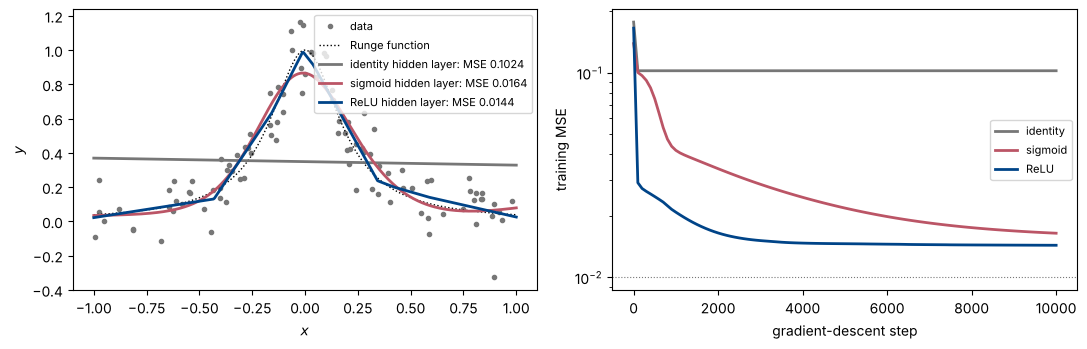

identity network = -0.0205 x + 0.3486


In [6]:
def identity(z):
    return z


def identity_der(z):
    return jnp.ones_like(z)


def train_gd(inputs, targets, layers, activation_funcs, activation_ders, gamma=0.1, n_steps=10000):
    history = []
    for step in range(n_steps):
        grads = backpropagation_batch(inputs, layers, activation_funcs, targets, activation_ders)
        layers = [(W - gamma*dW, b - gamma*db) for (W, b), (dW, db) in zip(layers, grads)]   # Eq. (8.70)
        if step % 100 == 0 or step == n_steps - 1:
            history.append(float(cost_batch(layers, inputs, activation_funcs, targets)))
    return layers, history


rng_data = np.random.default_rng(2026)
x_data = np.sort(rng_data.uniform(-1, 1, 100))
y_data = 1/(1 + 25*x_data**2) + rng_data.normal(0, 0.1, 100)
X_runge, Y_runge = x_data[:, None], y_data[:, None]
xx = np.linspace(-1, 1, 400)[:, None]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(X_runge, Y_runge, "o", color=GREY, ms=3, label="data")
ax[0].plot(xx, 1/(1 + 25*xx**2), "k:", lw=1, label="Runge function")
results = {}
for name, hidden, hidden_der, col, gamma in (("identity", identity, identity_der, GREY, 0.05),
                                             ("sigmoid", sigmoid, sigmoid_der, RED, 0.2),
                                             ("ReLU", ReLU, ReLU_der, BLUE, 0.1)):
    layers_r = create_layers_batch(1, [20, 1], np.random.default_rng(2026))
    layers_r, hist = train_gd(X_runge, Y_runge, layers_r, [hidden, identity], [hidden_der, identity_der], gamma=gamma)
    results[name] = (layers_r, hist)
    ax[0].plot(xx, feed_forward_batch(xx, layers_r, [hidden, identity]), color=col, lw=2,
               label=f"{name} hidden layer: MSE {hist[-1]:.4f}")
    ax[1].semilogy(100*np.arange(len(hist)), hist, color=col, lw=2, label=name)
    print(f"{name:9s} hidden activation, gamma {gamma}: training MSE {hist[-1]:.4f}")
print(f"the variance of y (predicting the mean): {Y_runge.var():.4f}")
ax[0].legend(fontsize=8); ax[0].set_xlabel("$x$"); ax[0].set_ylabel("$y$")
ax[1].legend(fontsize=8); ax[1].set_xlabel("gradient-descent step"); ax[1].set_ylabel("training MSE")
ax[1].axhline(0.01, color=GREY, lw=0.8, ls=":")
fig.tight_layout()
plt.show()

# the identity network really is one straight line: collapse the two layers
(W1, b1), (W2, b2) = results["identity"][0]
print(f"identity network = {float((W1 @ W2)[0, 0]):.4f} x + {float((b1 @ W2 + b2)[0]):.4f}")

**Checkpoint.** With the identity as hidden activation the 1–20–1 network
(41 parameters) *is* the straight line $\alpha x + \beta$ — collapse the two
layers by hand, $\boldsymbol{W}_1\boldsymbol{W}_2$ and $\boldsymbol{b}_1\boldsymbol{W}_2 +
\boldsymbol{b}_2$, and you get its two coefficients — and the best line through
the Runge data is the mean, MSE $0.10 = \mathrm{var}(y)$. The sigmoid and the
ReLU network reach $0.016$ and $0.014$ in ten thousand steps, close to the
noise floor $0.01$: twenty smooth steps, or twenty kinks, added with weights,
bend. The backward pass ran happily in all three
cases — with $f' = 1$ the gradient exists and gradient descent converges, to
the best *linear* model. Non-linearity is a property of the model, not of the
optimiser.

### Step 6 (optional) — training a classifier: softmax, cross entropy, SGD with momentum (exercise 7)

The digits data of week 41 (1797 images of $8\times8$ pixels, ten classes), a
64–32–10 network with `[sigmoid, softmax]`, the multiclass cross entropy, and
the shortcut of Eq. (8.69): do **not** differentiate the softmax and the
logarithm separately — for the last layer set `dC_dz = predict - target`
directly. The rest of the backward pass is untouched. Stochastic gradient
descent with momentum (Sections 4.6–4.7), $\gamma = 0.1$, $\beta = 0.9$,
minibatches of 32, train/test split 80/20.

In [7]:
def softmax(z):                                   # rows are samples, Eq. (5.30)
    e_z = jnp.exp(z - jnp.max(z, axis=1, keepdims=True))
    return e_z/jnp.sum(e_z, axis=1, keepdims=True)


def cross_entropy(predict, target):
    return -jnp.mean(jnp.sum(target*jnp.log(predict + 1e-12), axis=1))


def backpropagation_softmax(inputs, layers, activation_funcs, targets, activation_ders):
    """As backpropagation_batch, but the last layer is softmax + cross entropy: delta^L = (a^L - y)/n, Eq. (8.69)."""
    layer_inputs, zs, predict = feed_forward_saver_batch(inputs, layers, activation_funcs)
    layer_grads = [() for layer in layers]
    n = inputs.shape[0]
    for i in reversed(range(len(layers))):
        layer_input, z = layer_inputs[i], zs[i]
        if i == len(layers) - 1:
            dC_dz = (predict - targets)/n                 # the shortcut: no softmax Jacobian, no 1/a
        else:
            (W, b) = layers[i + 1]
            dC_dz = (dC_dz @ W.T) * activation_ders[i](z)
        layer_grads[i] = (layer_input.T @ dC_dz, np.sum(dC_dz, axis=0))
    return layer_grads


def accuracy(predictions, targets):
    return np.mean(np.argmax(predictions, axis=1) == np.argmax(targets, axis=1))


digits = datasets.load_digits()
X_all = digits.data/16.0                                  # pixels in [0, 1]
T_all = np.eye(10)[digits.target]                         # one-hot targets, shape (1797, 10)
X_tr, X_te, T_tr, T_te = train_test_split(X_all, T_all, test_size=0.2, random_state=2026)

layers_d = create_layers_batch(64, [32, 10], np.random.default_rng(2026))
acts, ders = [sigmoid, softmax], [sigmoid_der, None]

# check the shortcut against jax.grad of the full cost, once, before training
cost_ce = lambda layers, inputs, targets: cross_entropy(feed_forward_batch(inputs, layers, acts), targets)
g_hand = backpropagation_softmax(X_tr[:50], layers_d, acts, T_tr[:50], ders)
g_jax = jax.grad(cost_ce, argnums=0)(layers_d, X_tr[:50], T_tr[:50])
print("softmax shortcut agrees with jax.grad:", [(np.allclose(dW, dW_j), np.allclose(db, db_j))
                                                  for (dW, db), (dW_j, db_j) in zip(g_hand, g_jax)])

gamma, beta, M, epochs = 0.1, 0.9, 32, 50
velocity = [(np.zeros_like(W), np.zeros_like(b)) for W, b in layers_d]
rng_sgd = np.random.default_rng(2026)
print(f"before training: train accuracy {accuracy(feed_forward_batch(X_tr, layers_d, acts), T_tr):.3f}")
for epoch in range(1, epochs + 1):
    order = rng_sgd.permutation(len(X_tr))
    for s in range(0, len(X_tr), M):
        idx = order[s:s + M]
        grads = backpropagation_softmax(X_tr[idx], layers_d, acts, T_tr[idx], ders)
        velocity = [(beta*vW + gamma*dW, beta*vb + gamma*db) for (vW, vb), (dW, db) in zip(velocity, grads)]   # Eq. (4.28)
        layers_d = [(W - vW, b - vb) for (W, b), (vW, vb) in zip(layers_d, velocity)]
    if epoch in (1, 2, 5, 10, 20, 50):
        print(f"epoch {epoch:3d}: cost {float(cost_ce(layers_d, X_tr, T_tr)):.4f}  "
              f"train accuracy {accuracy(feed_forward_batch(X_tr, layers_d, acts), T_tr):.3f}  "
              f"test accuracy {accuracy(feed_forward_batch(X_te, layers_d, acts), T_te):.3f}")

softmax shortcut agrees with jax.grad: [(True, True), (True, True)]


before training: train accuracy 0.097


epoch   1: cost 1.5143  train accuracy 0.669  test accuracy 0.656
epoch   2: cost 0.5803  train accuracy 0.890  test accuracy 0.847
epoch   5: cost 0.2001  train accuracy 0.963  test accuracy 0.936


epoch  10: cost 0.1133  train accuracy 0.977  test accuracy 0.947


epoch  20: cost 0.0617  train accuracy 0.987  test accuracy 0.961


epoch  50: cost 0.0184  train accuracy 0.999  test accuracy 0.964


**Checkpoint.** The shortcut `dC_dz = predict - target` agrees with
`jax.grad` of the softmax + cross entropy — the softmax Jacobian and the
$1/a_k$ of the logarithm cancel exactly (Monday, and Section 5.6). Fifty epochs
of SGD with momentum on 1437 training images reach $96.4\%$ on the 360 test
images, from $9.7\%$ before training — and $99.9\%$ on the training images:
the gap is the variance term of Chapter 2, and the test accuracy stopped
improving after twenty epochs while the cost kept falling. The exercises ask for the same on the
iris data, with your own backpropagation and with momentum; compare with the
full-batch gradient descent of last week.

## Case 1: do you have the insight?

1. **Shapes.** $W$ has shape $(10, 4)$ and $b$ shape $(10,)$ in the
   single-vector convention. What are the shapes of $\partial C/\partial W$ and
   $\partial C/\partial b$, and of $\delta$? In the batched convention with $n$
   samples, which of these shapes change, and which products carry the sum
   over the samples?
2. **What is shared.** Which quantity do $\partial C/\partial W$ and
   $\partial C/\partial b$ of the same layer have in common, and why must the
   forward pass save every $z$ and every layer input before the backward pass
   can start? What would go wrong if you recomputed the forward pass *after*
   changing the weights of the last layer?
3. **The pull-back.** Why does the error travel backwards with $W^T$ and not
   with $W$? What does a ReLU node with $z < 0$ deliver to the layer below, and
   what does a sigmoid node with $|z| = 10$ deliver?
4. **Why the activation functions.** The 1–20–1 network with the identity as
   hidden activation fitted a straight line, the same network with sigmoid or
   ReLU units the Runge function. Which property of linear maps is responsible,
   what does the universal approximation theorem (Section 8.4) require of the
   activation, and in what sense is a ReLU network a sum of kinks? Does the
   backward pass "know" whether the network is non-linear?

**What we hope you say.** (1) The gradient of a scalar with respect to an
array has the shape of that array: $(10, 4)$ and $(10,)$; $\delta$ has the
shape of $z$, $(10,)$. Batched: $\delta$ becomes $(n, 10)$, the gradients keep
their shapes, and `layer_input.T @ dC_dz` and `np.sum(dC_dz, axis=0)` sum
over the samples. (2) The error $\delta = \partial C/\partial z$; the bias
gradient *is* $\delta$ and the weight gradient is $\delta$ times the layer
input; (8.66) needs $f'(z_l)$ and (8.68) needs $a_{l-1}$ at the parameters the
forward pass used — recomputing after an update mixes two networks and the
gradient is of neither. (3) $z_{l+1} = W a_l + b$ sends node $j$ of layer $l$
to *every* node $k$ of layer $l+1$ with weight $W_{kj}$; collecting the
contributions is $\sum_k W_{kj}\delta_k = (W^T\delta)_j$, the sum over the
receiving index. A dead ReLU node delivers exactly zero, a saturated sigmoid
node $\sigma'(10) \approx 5\times10^{-5}$ of what it received — the two faces
of the vanishing gradient. (4) The composition of linear maps is linear, so
depth without non-linearity adds parameters but no functions; the theorem
needs a non-polynomial activation; each ReLU unit is a kink at $-b_i/w_i$
and the output layer adds kinks with weights (Lemma 8.1). The backward pass is
the chain rule and works for any differentiable model, linear ones included;
the non-linearity lives in the model, and the optimiser only follows the
gradient.

## Wrap-up

- You now own a backward pass written by hand, in both weight conventions,
  with every shape in your head and `jax.grad` as the referee — and you have
  seen the three lines that change when the samples go into rows, the one line
  that changes for softmax + cross entropy, and the reason a network without
  activation functions is a linear model however deep it is.
- **Exercises week 42** (`exercisesweek42.ipynb`): the same six steps on the
  networks of the exercise set, then training on the iris data with SGD and
  momentum. Deadline **Friday October 16 at midnight**; hand in one notebook per
  group in Canvas, list your collaborators, finish the self-check table, and
  **declare your use of LLMs** (template at the end of the exercise notebook).
- **Project 2** (deadline November 6) is built on exactly this code: the
  batched backward pass of step 4 with the heads of Monday's Part 1.
- **Next Monday, week 43:** convolutional neural networks (Chapter 10).